In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Smart-Warehouse-Delay/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


# 
### **🤖 2. 로봇 / AGV 상태**
* robot_active → 작업 중인 로봇 수
* robot_idle → 대기 중인 로봇 수
* robot_charging → 충전 중인 로봇 수
* robot_utilization → 로봇 활용률
* avg_idle_duration_min → 평균 유휴 시간(분)
* agv_task_success_rate → AGV 작업 성공률
* robot_calibration_score → 로봇 보정 상태 점수

In [3]:
robot = df[["robot_active","robot_idle","robot_charging","robot_utilization",
        "avg_idle_duration_min","agv_task_success_rate","robot_calibration_score"]]
robot

,robot_active,robot_idle,robot_charging,robot_utilization,avg_idle_duration_min,agv_task_success_rate,robot_calibration_score
0,9,21,0,0.3000,5.15,0.9109,94.0
1,12,18,0,0.4000,3.55,NaN,NaN
2,16,14,0,0.5333,2.90,0.8966,86.1
3,13,17,0,0.4333,2.58,NaN,93.9
4,10,20,0,0.3333,3.25,0.8843,96.8
...,...,...,...,...,...,...,...
249995,7,71,0,0.0897,14.26,0.8542,NaN
249996,12,66,0,0.1538,13.27,0.8753,75.8
249997,11,67,0,0.1410,11.01,0.8644,NaN
249998,9,69,0,0.1154,13.73,0.8556,68.0


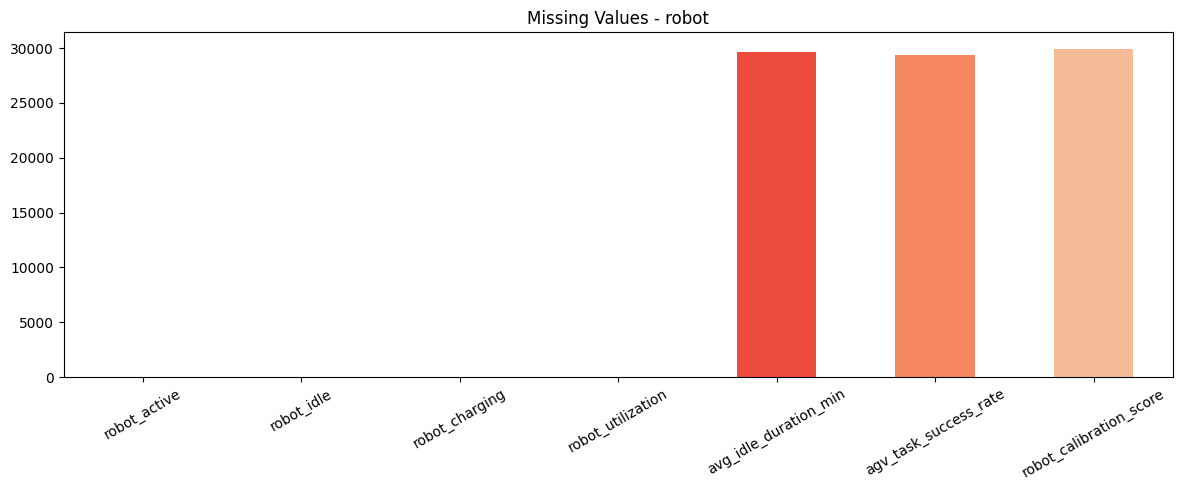

In [4]:
missing = robot.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - robot')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 
### **강한 상관관계**
robot_active ↔ robot_utilization = **0.76**  
robot_idle ↔ robot_utilization = -0.56  
robot_idle ↔ avg_idle_duration_min = 0.54

In [5]:
corr = robot.corr()
corr

,robot_active,robot_idle,robot_charging,robot_utilization,avg_idle_duration_min,agv_task_success_rate,robot_calibration_score
robot_active,1.000000,-0.219864,-0.078280,0.758620,-0.124246,0.317574,-0.007548
robot_idle,-0.219864,1.000000,-0.479412,-0.562773,0.546221,-0.237288,0.014234
robot_charging,-0.078280,-0.479412,1.000000,-0.113931,-0.266287,-0.042464,-0.019746
robot_utilization,0.758620,-0.562773,-0.113931,1.000000,-0.306588,0.419934,0.000130
avg_idle_duration_min,-0.124246,0.546221,-0.266287,-0.306588,1.000000,-0.132600,-0.006299
agv_task_success_rate,0.317574,-0.237288,-0.042464,0.419934,-0.132600,1.000000,0.009093
robot_calibration_score,-0.007548,0.014234,-0.019746,0.000130,-0.006299,0.009093,1.000000


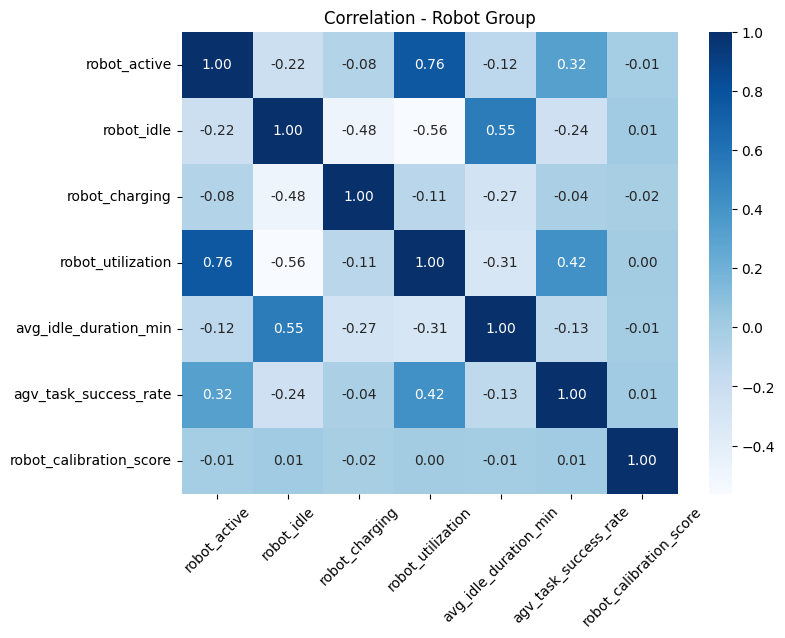

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Robot Group')
plt.xticks(rotation=45)
plt.show()